# Great Basin post-fire annual herbaceous cover

Shared working notebook for the class project.

**Question:** do burned areas in the Great Basin show greater post-fire increases in annual herbaceous cover, as a proxy for invasive annual grass expansion, compared with unburned areas nearby?

This notebook walks through the full setup end-to-end so anyone cloning the repo can reproduce it from raw downloads:

1. **Setup** â€” imports, paths, project CRS
2. **Great Basin boundary** â€” load and reproject to the project CRS
3. **MTBS preprocessing** â€” load, clean attributes, reproject, filter to fires inside the Great Basin
4. **RCMAP preprocessing** â€” clip each annual raster to the Great Basin polygon (writes cleaned files to `data/processed/rcmap/`)
5. **Overview map** â€” study area with fire perimeters


See `ANALYSIS_PLAN.md` for next steps.

## 1. Setup

We work in **EPSG:5070** (CONUS Albers Equal Area) as the project CRS, because RCMAP is published in that CRS and equal-area projections are appropriate for area-based summaries.

In [37]:
# Import required libraries
from pathlib import Path
import geopandas as gpd  # For vector (shapefile/polygon) operations
import matplotlib.pyplot as plt  # For creating maps and plots
import numpy as np  # For numerical operations
import pandas as pd  # For tabular data handling
import rasterio  # For reading/writing raster files (RCMAP, etc.)
from rasterio.mask import mask  # For clipping rasters to polygons

# Define data directory structure
DATA = Path('data')

# Input file paths (raw data)
BOUNDARY = DATA / 'raw' / 'boundaries' / 'great_basin_huc2_16_wbd.geojson'
MTBS_RAW = DATA / 'raw' / 'mtbs' / 'mtbs_perims_DD.shp'
RCMAP_RAW_DIR = DATA / 'raw' / 'rcmap'

# Output file paths (processed data)
MTBS_CLEAN = DATA / 'processed' / 'mtbs' / 'mtbs_great_basin_cleaned.gpkg'
RCMAP_CLIPPED_DIR = DATA / 'processed' / 'rcmap'

# Create output directories if they don't exist
MTBS_CLEAN.parent.mkdir(parents=True, exist_ok=True)
RCMAP_CLIPPED_DIR.mkdir(parents=True, exist_ok=True)

# Project settings
PROJECT_CRS = 'EPSG:5070'  # CONUS Albers Equal Area - preserves area measurements
RCMAP_YEARS = range(2012, 2021)  # Years of RCMAP data we have available
RCMAP_NODATA = 101  # RCMAP uses 101 to indicate no data

## 2. Great Basin boundary

Load and reproject to the project CRS.

In [38]:
# Load Great Basin boundary and reproject to project CRS
gb = gpd.read_file(BOUNDARY).to_crs(PROJECT_CRS)
print('Great Basin polygon:', len(gb), 'feature(s), CRS =', gb.crs)
gb.head()

Great Basin polygon: 1 feature(s), CRS = EPSG:5070


,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc2,name,globalid,Shape__Length,Shape__Area,geometry
0,12,{9567C98F-F09E-4C52-B2ED-C770AC69261B},None,None,None,None,1606734056000,None,90699696.71,367048.97,"CA,ID,NV,OR,UT,WY",16,Great Basin Region,{64F307DD-6EAB-4D6F-8AB2-812723B9B30D},8.630435e+06,6.220980e+11,"POLYGON ((-1265740.859 2310584.744, -1265806.6..."


## 3. MTBS preprocessing

The raw MTBS shapefile is nationwide. We:

1. Load it
2. Parse `Ig_Date` into a real datetime and derive `IgnitionYear`
3. Drop rows missing critical attributes (ignition date, geometry, acreage)
4. Reproject to the project CRS
5. Spatial-join to keep only fires intersecting the Great Basin polygon
6. Write the cleaned subset to `data/processed/mtbs/` as a GeoPackage

In [39]:
# Load raw MTBS fire perimeters (nationwide dataset)
mtbs = gpd.read_file(MTBS_RAW)
print('MTBS raw:', len(mtbs), 'rows, CRS =', mtbs.crs)

# MTBS columns are lowercase so renaming
mtbs = mtbs.rename(columns={
    'ig_date':    'Ig_Date',
    'event_id':   'Event_ID',
    'incid_name': 'Incid_Name',
    'burnbndac':  'BurnBndAc',
})

# Parse ignition date and extract year
mtbs['Ig_Date'] = pd.to_datetime(mtbs['Ig_Date'], errors='coerce')
mtbs['IgnitionYear'] = mtbs['Ig_Date'].dt.year

# Remove fires with missing critical attributes
before = len(mtbs)
mtbs = mtbs.dropna(subset=['Ig_Date', 'geometry', 'BurnBndAc']).copy()
mtbs = mtbs[mtbs.geometry.is_valid & ~mtbs.geometry.is_empty]
print(f'Dropped {before - len(mtbs)} rows with missing/invalid attributes or geometry')

# Reproject to our project CRS (EPSG:5070)
mtbs = mtbs.to_crs(PROJECT_CRS)
print('MTBS reprojected to', mtbs.crs)

MTBS raw: 30390 rows, CRS = EPSG:4269
Dropped 57 rows with missing/invalid attributes or geometry
MTBS reprojected to EPSG:5070


In [40]:
# Spatial join: keep only fires that intersect the Great Basin polygon
fires = gpd.sjoin(mtbs, gb[['geometry']], predicate='intersects', how='inner')
fires = fires.drop(columns=['index_right']).reset_index(drop=True)
print(f'Fires intersecting the Great Basin: {len(fires)}')

# Save cleaned fire perimeters for reuse
fires.to_file(MTBS_CLEAN, driver='GPKG')
print('Wrote cleaned MTBS to', MTBS_CLEAN)
fires[['Event_ID', 'Incid_Name', 'Ig_Date', 'IgnitionYear', 'BurnBndAc']].head()

Fires intersecting the Great Basin: 1449
Wrote cleaned MTBS to data\processed\mtbs\mtbs_great_basin_cleaned.gpkg


,Event_ID,Incid_Name,Ig_Date,IgnitionYear,BurnBndAc
0,UT4176411148820121004,HELLS HOLLOW,2012-10-04,2012,4756
1,UT4054911295520120727,DALLAS CANYON,2012-07-27,2012,43385
2,UT4000611394320120729,IBAPAH,2012-07-29,2012,1577
3,NV3927511478820120702,RANGE,2012-07-02,2012,4883
4,NV3872111500020120630,EGAN,2012-06-30,2012,7244


## 4. RCMAP preprocessing â€” clip to Great Basin

RCMAP rasters are published as CONUS-wide mosaics. We clip each annual raster to the Great Basin polygon and write the result to `data/processed/rcmap/`. This keeps the pre/post extraction step fast.

This cell is **idempotent**: if the clipped file already exists, it is skipped.

In [41]:
def clip_rcmap_year(year):
    """
    Clip a single RCMAP raster to the Great Basin boundary.
    If the clipped file already exists, skip it (idempotent).
    """
    src_path = RCMAP_RAW_DIR / f'rcmap_annual_herbaceous_{year}.tif'
    dst_path = RCMAP_CLIPPED_DIR / f'rcmap_annual_herbaceous_{year}_great_basin_clipped.tif'
    
    # Skip if already processed
    if dst_path.exists():
        return dst_path, 'skipped (exists)'
    
    # Check if raw file exists
    if not src_path.exists():
        return dst_path, f'missing raw: {src_path}'
    
    # Open raster, clip to Great Basin, and save
    with rasterio.open(src_path) as src:
        # Reproject Great Basin boundary to match raster CRS
        gb_in_src = gb.to_crs(src.crs)
        # Clip raster to boundary
        arr, transform = mask(src, gb_in_src.geometry, crop=True, filled=True, nodata=RCMAP_NODATA)
        # Update metadata for the clipped raster
        profile = src.profile.copy()
        profile.update(height=arr.shape[1], width=arr.shape[2], transform=transform, nodata=RCMAP_NODATA)
    
    # Write clipped raster
    with rasterio.open(dst_path, 'w', **profile) as dst:
        dst.write(arr)
    
    return dst_path, 'written'

# Clip all RCMAP years
for yr in RCMAP_YEARS:
    path, status = clip_rcmap_year(yr)
    print(f'{yr}: {status:20s} -> {path.name}')

2012: skipped (exists)     -> rcmap_annual_herbaceous_2012_great_basin_clipped.tif
2013: skipped (exists)     -> rcmap_annual_herbaceous_2013_great_basin_clipped.tif
2014: skipped (exists)     -> rcmap_annual_herbaceous_2014_great_basin_clipped.tif
2015: skipped (exists)     -> rcmap_annual_herbaceous_2015_great_basin_clipped.tif
2016: skipped (exists)     -> rcmap_annual_herbaceous_2016_great_basin_clipped.tif
2017: skipped (exists)     -> rcmap_annual_herbaceous_2017_great_basin_clipped.tif
2018: skipped (exists)     -> rcmap_annual_herbaceous_2018_great_basin_clipped.tif
2019: skipped (exists)     -> rcmap_annual_herbaceous_2019_great_basin_clipped.tif
2020: skipped (exists)     -> rcmap_annual_herbaceous_2020_great_basin_clipped.tif


In [42]:
# Inspect one clipped raster to verify properties
sample_year = 2016
sample_path = RCMAP_CLIPPED_DIR / f'rcmap_annual_herbaceous_{sample_year}_great_basin_clipped.tif'
with rasterio.open(sample_path) as src:
    print('CRS        :', src.crs)
    print('Shape      :', src.height, 'x', src.width)
    print('Resolution :', src.res)
    print('Dtype      :', src.dtypes[0])
    print('Nodata     :', src.nodata)

CRS        : EPSG:5070
Shape      : 28007 x 29030
Resolution : (30.0, 30.0)
Dtype      : uint8
Nodata     : 101.0


## 5. Overview map

Great Basin polygon with fire perimeters overlaid.

C:\Users\owusu\AppData\Local\Temp\ipykernel_36876\1359071013.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', frameon=True, framealpha=0.95)
C:\Users\owusu\AppData\Local\Temp\ipykernel_36876\1359071013.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=True, framealpha=0.95)


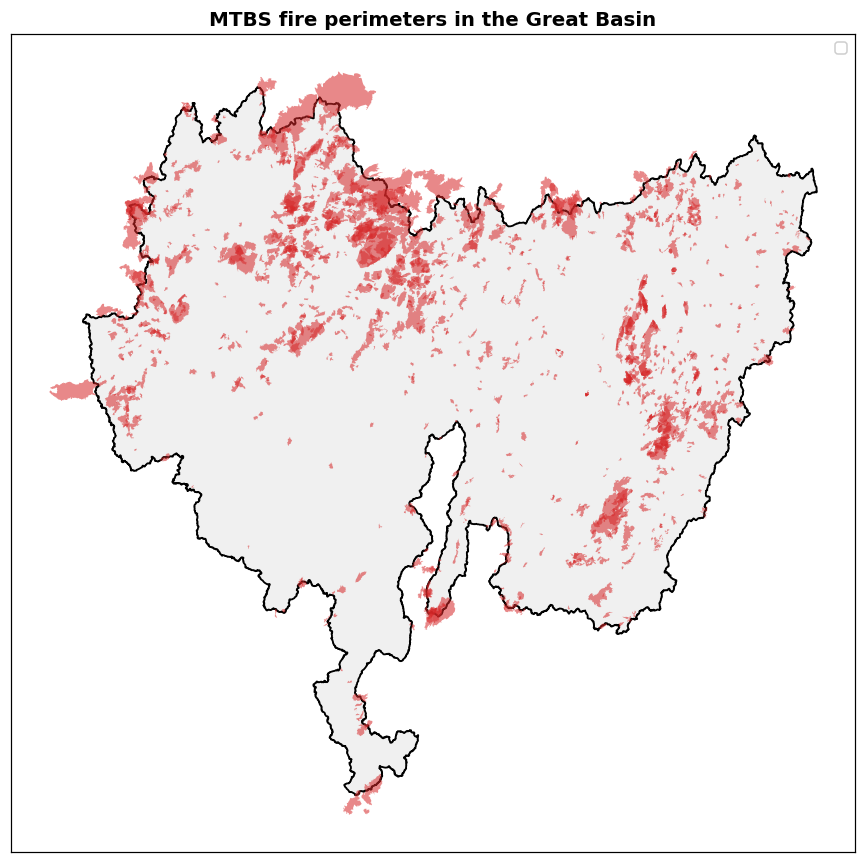

In [43]:
# Figure 1: Study area map - Great Basin with all MTBS fire perimeters
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Consistent publication-quality styling
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

fig, ax = plt.subplots(figsize=(8, 9))

# Great Basin polygon (filled light gray, dark outline)
gb.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=1.2)

# Fire perimeters
fires.plot(ax=ax, facecolor='#d62728', edgecolor='none', alpha=0.55,
           label=f'MTBS fires (n = {len(fires):,})')

ax.set_title('MTBS fire perimeters in the Great Basin', fontweight='bold')
ax.legend(loc='upper right', frameon=True, framealpha=0.95)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_study_area.png')
plt.show()

## Phase 2: Burned-area summary

Scale the single-fire extraction to all eligible fires. For each fire with ignition year **2014â€“2018**, compute pre-fire (mean of the **2 years before**) and post-fire (mean of the **2 years after**) annual herbaceous cover.

Using a 2-year window smooths out single-year weather variability (e.g. drought years) while keeping a reasonable sample size.

### Helper functions and parameters

In [44]:
# Import additional libraries for Phase 2
from contextlib import ExitStack  # For managing multiple open files efficiently
from shapely import make_valid  # For fixing invalid geometries
from shapely.geometry import mapping  # For converting geometries to GeoJSON format

# Pre/post window length (years on each side of the fire)
WINDOW = 2

# Eligible ignition years: need RCMAP for [year-WINDOW, year-1] AND [year+1, year+WINDOW]
# RCMAP coverage is 2012-2020, so with WINDOW=2 eligible years are 2014-2018
ELIGIBLE_IGNITION_YEARS = list(range(2012 + WINDOW, 2021 - WINDOW))  # 2014-2018

def rcmap_clipped_path(year):
    """Return path to a clipped RCMAP raster for a given year."""
    return RCMAP_CLIPPED_DIR / f"rcmap_annual_herbaceous_{year}_great_basin_clipped.tif"

def zonal_mean_improved(src, geom):
    """
    Extract mean raster value inside a geometry, excluding nodata pixels.
    
    Args:
        src: Open rasterio dataset
        geom: Shapely geometry (fire perimeter)
    
    Returns:
        (mean_value, pixel_count) or (np.nan, 0) if extraction fails
    """
    try:
        # Clip raster to geometry
        data, _ = mask(src, [mapping(geom)], crop=True,
                       nodata=src.nodata, filled=True, all_touched=False)
    except ValueError:
        return np.nan, 0
    
    # Convert to float and find valid pixels
    band = data[0].astype("float32")
    valid = np.isfinite(band)
    if src.nodata is not None:
        valid &= band != src.nodata
    
    # Calculate mean of valid pixels
    n = int(valid.sum())
    if n == 0:
        return np.nan, 0
    
    return float(band[valid].mean()), n

def multi_year_mean(rasters, years, geom):
    """
    Average zonal_mean_improved across multiple years.
    Returns (mean_of_means, min_pixel_count) â€” NaN if any year has no valid pixels.
    """
    means, counts = [], []
    for y in years:
        m, n = zonal_mean_improved(rasters[y], geom)
        if np.isnan(m):
            return np.nan, 0
        means.append(m)
        counts.append(n)
    return float(np.mean(means)), int(min(counts))

### Filter fires to eligible ignition years

In [10]:
# Reload the cleaned fires from Phase 1
fires_all = gpd.read_file(MTBS_CLEAN)

# Filter to eligible ignition years (need RCMAP data for the full pre/post window)
fires_eligible = fires_all[fires_all["IgnitionYear"].isin(ELIGIBLE_IGNITION_YEARS)].copy()

# Build pre/post year lists for each fire (2 years on each side of ignition)
fires_eligible["PreFireYears"]  = fires_eligible["IgnitionYear"].apply(
    lambda y: list(range(int(y) - WINDOW, int(y))))
fires_eligible["PostFireYears"] = fires_eligible["IgnitionYear"].apply(
    lambda y: list(range(int(y) + 1, int(y) + 1 + WINDOW)))
fires_eligible["BurnedAreaSqKm"] = fires_eligible.geometry.area / 1_000_000

# Summary
print(f"Total fires in cleaned MTBS: {len(fires_all)}")
print(f"Eligible fires (ignition {min(ELIGIBLE_IGNITION_YEARS)}-{max(ELIGIBLE_IGNITION_YEARS)}): {len(fires_eligible)}")
print(f"Pre/post window: {WINDOW} years on each side")
print("\nFires by ignition year:")
print(fires_eligible["IgnitionYear"].value_counts().sort_index())

Total fires in cleaned MTBS: 1449
Eligible fires (ignition 2014-2018): 202
Pre/post window: 2 years on each side

Fires by ignition year:
IgnitionYear
2014    15
2015    10
2016    43
2017    83
2018    51
Name: count, dtype: int64


### Extract pre/post RCMAP means for all fires

Opens all RCMAP rasters once and loops over eligible fires. This may take a few minutes.

In [11]:
records = []

# Use ExitStack to open all RCMAP rasters at once (more efficient than opening/closing repeatedly)
with ExitStack() as stack:
    # Open all RCMAP years and keep them open
    rasters = {y: stack.enter_context(rasterio.open(rcmap_clipped_path(y))) 
               for y in RCMAP_YEARS}
    
    # Loop over each eligible fire
    for idx, row in fires_eligible.iterrows():
        pre_years  = row.PreFireYears   # e.g. [2014, 2015] for a 2016 fire
        post_years = row.PostFireYears  # e.g. [2017, 2018] for a 2016 fire
        
        # Mean annual herbaceous cover averaged across the pre/post windows
        pre_mean,  pre_n  = multi_year_mean(rasters, pre_years,  row.geometry)
        post_mean, post_n = multi_year_mean(rasters, post_years, row.geometry)
        
        # Skip fires where extraction failed for any year in the window
        if np.isnan(pre_mean) or np.isnan(post_mean):
            continue
        
        records.append({
            "Event_ID":       row.Event_ID,
            "Incid_Name":     row.Incid_Name,
            "IgnitionYear":   int(row.IgnitionYear),
            "PreFireYears":   pre_years,
            "PostFireYears":  post_years,
            "BurnBndAc":      row.BurnBndAc,
            "BurnedAreaSqKm": row.BurnedAreaSqKm,
            "PreMean":        pre_mean,             # Mean % cover across pre-fire window
            "PostMean":       post_mean,            # Mean % cover across post-fire window
            "AbsChange":      post_mean - pre_mean, # Change in % cover
            "PrePixels":      pre_n,                # Min valid pixel count across pre years
            "PostPixels":     post_n,
        })

# Convert to DataFrame and sort by year and fire ID
pre_post = pd.DataFrame(records).sort_values(["IgnitionYear","Event_ID"]).reset_index(drop=True)
print(f"Fires with valid pre + post means: {len(pre_post)}")
pre_post.head(10)

Fires with valid pre + post means: 202


,Event_ID,Incid_Name,IgnitionYear,PreFireYears,PostFireYears,BurnBndAc,BurnedAreaSqKm,PreMean,PostMean,AbsChange,PrePixels,PostPixels
0,NV3827811551720140715,BEAR TRAP,2014,"[2012, 2013]","[2015, 2016]",10711,43.371113,0.031383,0.127907,0.096524,38094,38094
1,NV3924811413320140716,HAMPTON,2014,"[2012, 2013]","[2015, 2016]",11683,47.248313,0.257042,0.510256,0.253214,52505,52505
2,NV4000011456620140724,SAMPSON,2014,"[2012, 2013]","[2015, 2016]",1941,7.850982,2.817438,7.247195,4.429757,8734,8734
3,NV4005311462120140702,LAGES,2014,"[2012, 2013]","[2015, 2016]",8128,32.857347,0.471506,6.258777,5.787271,36516,36516
4,NV4105311638320140729,BOOTSTRAP,2014,"[2012, 2013]","[2015, 2016]",1385,5.610510,7.009626,23.447618,16.437992,6233,6233
5,NV4123411748320140712,LUCKY,2014,"[2012, 2013]","[2015, 2016]",9494,38.474440,38.129230,38.292063,0.162832,42753,42753
6,NV4192811977620140702,COLEMAN,2014,"[2012, 2013]","[2015, 2016]",15009,60.702088,12.089248,18.888748,6.799500,32197,32197
7,OR4201411871120140711,DENIO BASIN,2014,"[2012, 2013]","[2015, 2016]",1763,7.145750,4.204545,9.625000,5.420455,44,44
8,UT3953011186520140724,LEVAN,2014,"[2012, 2013]","[2015, 2016]",4353,17.630370,3.637004,6.000460,2.363455,19576,19576
9,UT3993311271820140721,LION PEAK,2014,"[2012, 2013]","[2015, 2016]",1172,4.742199,2.389174,3.459734,1.070560,5265,5265


### Phase 2 Summary Statistics

In [23]:
# Calculate and display summary statistics for Phase 2
print(f"Fires analysed: {len(pre_post)}")
print(f"Mean pre-fire cover : {pre_post['PreMean'].mean():.2f}%")
print(f"Mean post-fire cover: {pre_post['PostMean'].mean():.2f}%")
print(f"Mean absolute change: {pre_post['AbsChange'].mean():+.2f} percentage points")
print(f"Fires with increase : {(pre_post['AbsChange'] > 0).sum()}")
print(f"Fires with decrease : {(pre_post['AbsChange'] < 0).sum()}")
print("\nDescriptive statistics:")
pre_post[['PreMean','PostMean','AbsChange']].describe().round(2)

Fires analysed: 266
Mean pre-fire cover : 18.38%
Mean post-fire cover: 19.60%
Mean absolute change: +1.22 percentage points
Fires with increase : 176
Fires with decrease : 85

Descriptive statistics:


,PreMean,PostMean,AbsChange
count,266.00,266.00,266.00
mean,18.38,19.60,1.22
std,13.39,12.92,8.03
min,0.00,0.00,-40.34
25%,6.41,9.22,-1.70
50%,17.52,18.93,1.62
75%,28.21,28.83,5.83
max,66.85,63.21,23.78


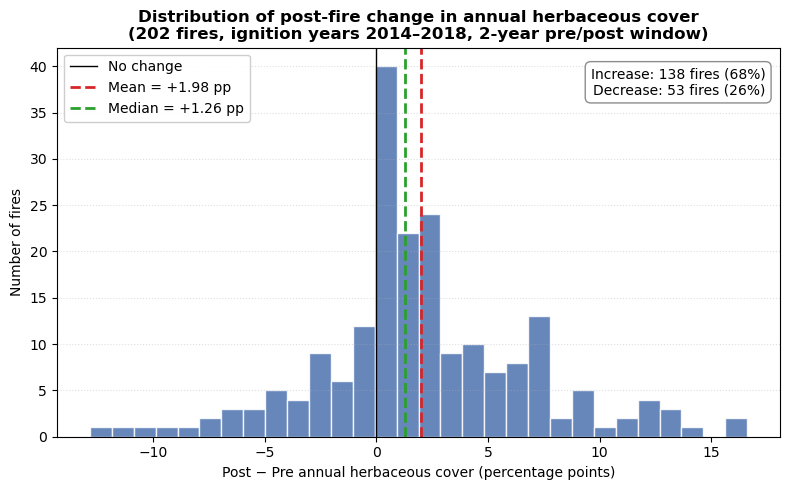

In [17]:
# Figure 2: Histogram of pre/post change in annual herbaceous cover
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

mean_change   = pre_post['AbsChange'].mean()
median_change = pre_post['AbsChange'].median()
n_increase    = (pre_post['AbsChange'] > 0).sum()
n_decrease    = (pre_post['AbsChange'] < 0).sum()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(pre_post['AbsChange'], bins=30, color='#4c72b0',
        edgecolor='white', alpha=0.85)

# Reference lines
ax.axvline(0, color='black', linestyle='-', linewidth=1, label='No change')
ax.axvline(mean_change, color='#d62728', linestyle='--', linewidth=2,
           label=f'Mean = {mean_change:+.2f} pp')
ax.axvline(median_change, color='#2ca02c', linestyle='--', linewidth=2,
           label=f'Median = {median_change:+.2f} pp')

# Annotate split
ax.text(0.98, 0.95,
        f'Increase: {n_increase} fires ({n_increase/len(pre_post)*100:.0f}%)\n'
        f'Decrease: {n_decrease} fires ({n_decrease/len(pre_post)*100:.0f}%)',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='gray', alpha=0.9))

ax.set_xlabel('Post âˆ’ Pre annual herbaceous cover (percentage points)')
ax.set_ylabel('Number of fires')
ax.set_title('Distribution of post-fire change in annual herbaceous cover\n'
             f'({len(pre_post)} fires, ignition years 2014â€“2018, 2-year pre/post window)',
             fontweight='bold')
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_change_histogram.png')
plt.show()

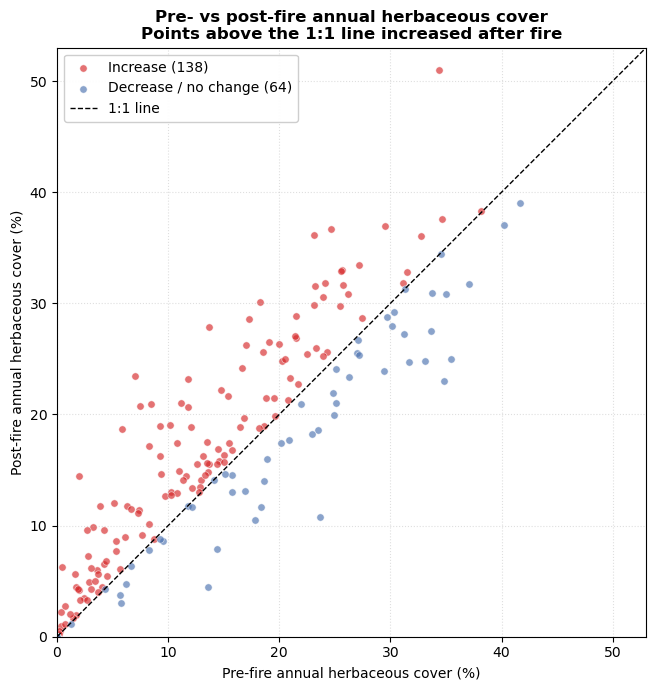

In [18]:
# Figure 3: Pre-fire vs post-fire mean cover (1:1 line)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 7))

# Color points by direction of change
increased = pre_post['AbsChange'] > 0
ax.scatter(pre_post.loc[increased,  'PreMean'], pre_post.loc[increased,  'PostMean'],
           s=28, color='#d62728', alpha=0.65, edgecolor='white', linewidth=0.5,
           label=f'Increase ({increased.sum()})')
ax.scatter(pre_post.loc[~increased, 'PreMean'], pre_post.loc[~increased, 'PostMean'],
           s=28, color='#4c72b0', alpha=0.65, edgecolor='white', linewidth=0.5,
           label=f'Decrease / no change ({(~increased).sum()})')

# 1:1 reference line
lo = 0
hi = max(pre_post['PreMean'].max(), pre_post['PostMean'].max()) + 2
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1, label='1:1 line')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('Pre-fire annual herbaceous cover (%)')
ax.set_ylabel('Post-fire annual herbaceous cover (%)')
ax.set_title('Pre- vs post-fire annual herbaceous cover\n'
             'Points above the 1:1 line increased after fire',
             fontweight='bold')
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_pre_vs_post_scatter.png')
plt.show()

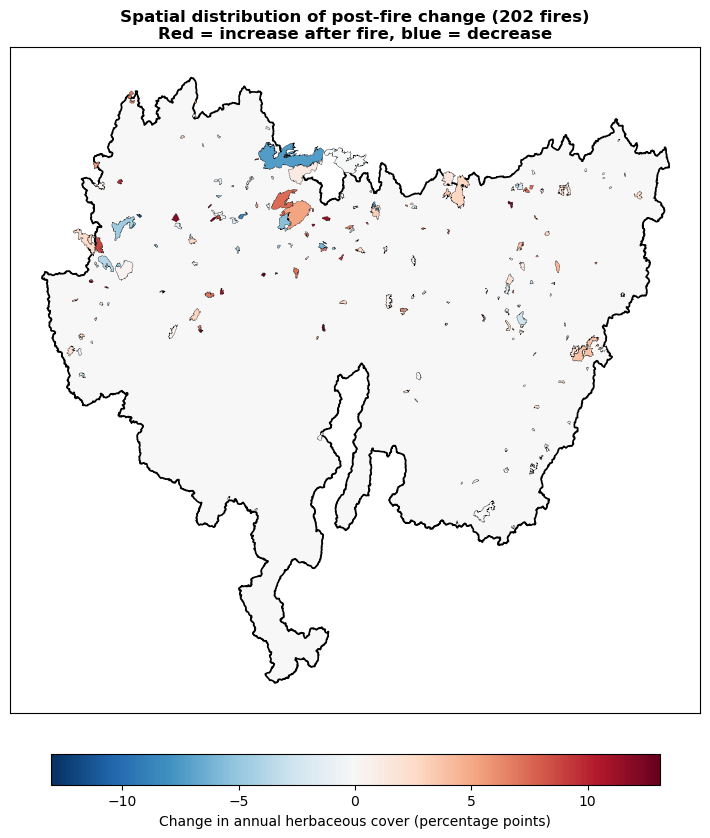

In [19]:
# Figure 4: Map of fires colored by post-fire change
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

# Merge AbsChange back onto fire geometries
fires_mapped = fires_eligible.merge(
    pre_post[['Event_ID', 'AbsChange']], on='Event_ID', how='inner'
)

# Symmetric color limits centered on zero
v = max(abs(fires_mapped['AbsChange'].quantile(0.02)),
        abs(fires_mapped['AbsChange'].quantile(0.98)))

fig, ax = plt.subplots(figsize=(9, 9))

# Great Basin background
gb.plot(ax=ax, facecolor='#f7f7f7', edgecolor='black', linewidth=1.2)

# Fires colored by AbsChange (red = increase, blue = decrease)
fires_mapped.plot(
    ax=ax, column='AbsChange', cmap='RdBu_r',
    vmin=-v, vmax=v,
    edgecolor='black', linewidth=0.2,
    legend=True,
    legend_kwds={
        'label': 'Change in annual herbaceous cover (percentage points)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.05,
    },
)

ax.set_title(f'Spatial distribution of post-fire change ({len(fires_mapped)} fires)\n'
             f'Red = increase after fire, blue = decrease',
             fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_change_map.png')
plt.show()

## Phase 3: Burned vs unburned comparison

For each of the 202 analyzed fires, we build an **unburned control "ring"** â€” a 1 km buffer immediately outside the fire perimeter â€” and extract the same 2-year pre/post mean annual herbaceous cover inside the ring.

**Control ring construction:**
1. Buffer the fire perimeter by 1 km
2. Subtract the original perimeter (so the ring is a donut, not a disc)
3. Remove any pixels that fall inside *other* MTBS fires (so we never compare burned to burned)
4. Clip to the Great Basin polygon

**Why this matters:** The burned-area increase from Phase 2 (+1.98 pp on average) could simply reflect a regional climate signal â€” e.g. wetter post-fire years driving annual herbaceous cover up everywhere, not just inside fire perimeters. By subtracting the change in nearby unburned controls, we isolate the **fire-attributable** change:

> AttributableChange = (Post_burned âˆ’ Pre_burned) âˆ’ (Post_control âˆ’ Pre_control)

We then run paired statistical tests (paired t-test and Wilcoxon signed-rank) on the burned vs control changes, since each fire has its own paired control.

In [20]:
# Phase 3 parameters
RING_DISTANCE_M = 1000  # 1 km buffer outside each fire perimeter

# Pre-compute the union of ALL MTBS fire perimeters in the Great Basin.
# Used to subtract burned pixels from the control rings (so we never compare burned to burned).
print('Building union of all fire perimeters...')
all_fires_union = fires_all.geometry.unary_union
gb_geom = gb.geometry.iloc[0]
print('Done.')

def build_control_ring(fire_geom, buffer_m=RING_DISTANCE_M):
    """
    Construct an unburned control ring around a fire perimeter:
      buffer(fire, buffer_m) - fire - all_other_fires, clipped to the Great Basin.
    Returns None if the resulting ring is empty.
    """
    buffered = fire_geom.buffer(buffer_m)
    ring = buffered.difference(fire_geom)
    ring = ring.difference(all_fires_union)  # remove pixels overlapping any other MTBS fire
    ring = ring.intersection(gb_geom)        # clip to Great Basin
    return ring if not ring.is_empty else None

Building union of all fire perimeters...


C:\Users\owusu\AppData\Local\Temp\ipykernel_36876\428225581.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  all_fires_union = fires_all.geometry.unary_union


Done.


### Extract pre/post means inside each control ring

Same 2-year pre/post window, same `multi_year_mean()` extraction â€” applied to the control ring instead of the fire perimeter.

In [21]:
control_records = []
skipped_empty_ring = 0
skipped_no_pixels  = 0

with ExitStack() as stack:
    rasters = {y: stack.enter_context(rasterio.open(rcmap_clipped_path(y))) for y in RCMAP_YEARS}
    
    for idx, row in fires_eligible.iterrows():
        ring_geom = build_control_ring(row.geometry)
        if ring_geom is None:
            skipped_empty_ring += 1
            continue
        
        pre_mean,  pre_n  = multi_year_mean(rasters, row.PreFireYears,  ring_geom)
        post_mean, post_n = multi_year_mean(rasters, row.PostFireYears, ring_geom)
        
        if np.isnan(pre_mean) or np.isnan(post_mean):
            skipped_no_pixels += 1
            continue
        
        control_records.append({
            'Event_ID':       row.Event_ID,
            'CtrlPreMean':    pre_mean,
            'CtrlPostMean':   post_mean,
            'CtrlChange':     post_mean - pre_mean,
            'CtrlPrePixels':  pre_n,
            'CtrlPostPixels': post_n,
        })

control_df = pd.DataFrame(control_records)
print(f'Control rings extracted: {len(control_df)}')
print(f'  Skipped (empty ring after exclusions): {skipped_empty_ring}')
print(f'  Skipped (no valid pixels):             {skipped_no_pixels}')
control_df.head()

Control rings extracted: 198
  Skipped (empty ring after exclusions): 4
  Skipped (no valid pixels):             0


,Event_ID,CtrlPreMean,CtrlPostMean,CtrlChange,CtrlPrePixels,CtrlPostPixels
0,NV4123411748320140712,32.912576,34.496847,1.584271,52812,52812
1,NV4105311638320140729,14.030754,18.983287,4.952533,13852,13852
2,NV4192811977620140702,13.161139,13.981970,0.820831,29701,29701
3,OR4201411871120140711,5.792120,5.834341,0.042221,4962,4962
4,NV4005311462120140702,1.053177,1.105093,0.051916,43628,43628


### Combine burned + control, and compute fire-attributable change

For each fire, we now have a paired observation:
- `AbsChange` â€” change inside the burned perimeter (Phase 2)
- `CtrlChange` â€” change inside the surrounding 1 km unburned ring
- `AttributableChange` = `AbsChange` âˆ’ `CtrlChange` (the fire-driven portion of the change)

In [22]:
from scipy import stats

# Inner join: keep only fires that have BOTH burned and control measurements
combined = pre_post.merge(control_df, on='Event_ID', how='inner')
combined['AttributableChange'] = combined['AbsChange'] - combined['CtrlChange']

print(f'Paired fires (both burned + control): {len(combined)}')
print(f'\nMean burned change       : {combined["AbsChange"].mean():+.2f} pp')
print(f'Mean control change      : {combined["CtrlChange"].mean():+.2f} pp')
print(f'Mean attributable change : {combined["AttributableChange"].mean():+.2f} pp')

# Paired statistical tests: is burned change > control change across the 202 fires?
t_stat, p_t = stats.ttest_rel(combined['AbsChange'], combined['CtrlChange'])
w_stat, p_w = stats.wilcoxon(combined['AbsChange'], combined['CtrlChange'])

print(f'\nPaired t-test:        t = {t_stat:.3f}, p = {p_t:.2e}')
print(f'Wilcoxon signed-rank: W = {w_stat:.0f}, p = {p_w:.2e}')

# Fraction where burned > control
n_burned_greater = (combined['AttributableChange'] > 0).sum()
print(f'\nFires where burned change > control change: {n_burned_greater} / {len(combined)} '
      f'({n_burned_greater/len(combined)*100:.0f}%)')

print('\nDescriptive stats (paired):')
combined[['AbsChange','CtrlChange','AttributableChange']].describe().round(2)

Paired fires (both burned + control): 198

Mean burned change       : +1.91 pp
Mean control change      : -0.08 pp
Mean attributable change : +1.99 pp

Paired t-test:        t = 7.440, p = 3.04e-12
Wilcoxon signed-rank: W = 3587, p = 1.35e-12

Fires where burned change > control change: 142 / 198 (72%)

Descriptive stats (paired):


,AbsChange,CtrlChange,AttributableChange
count,198.00,198.00,198.00
mean,1.91,-0.08,1.99
std,4.80,1.80,3.76
min,-12.84,-7.84,-10.46
25%,-0.02,-0.25,0.00
50%,1.26,0.00,1.62
75%,4.39,0.36,4.26
max,16.61,9.08,13.80


### Phase 3 figures

figures visualizing the burned vs unburned comparison.

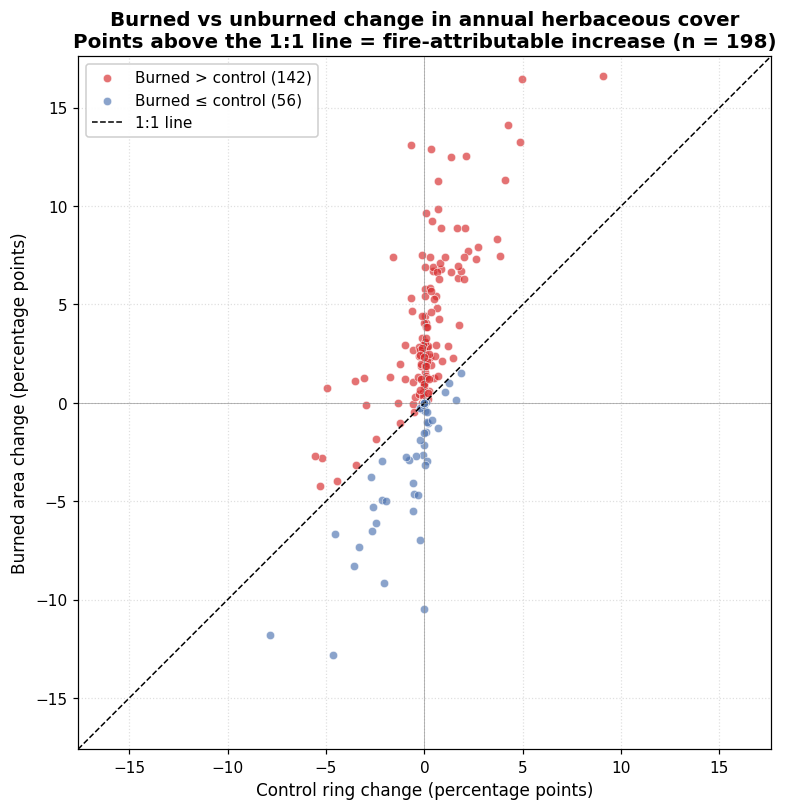

In [45]:
# Figure 5: Burned change vs control change (paired scatter with 1:1 line)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Color points by sign of attributable change (burned > control = red)
above = combined['AttributableChange'] > 0
ax.scatter(combined.loc[above,  'CtrlChange'], combined.loc[above,  'AbsChange'],
           s=30, color='#d62728', alpha=0.65, edgecolor='white', linewidth=0.5,
           label=f'Burned > control ({above.sum()})')
ax.scatter(combined.loc[~above, 'CtrlChange'], combined.loc[~above, 'AbsChange'],
           s=30, color='#4c72b0', alpha=0.65, edgecolor='white', linewidth=0.5,
           label=f'Burned ≤ control ({(~above).sum()})')

# 1:1 line
lim = max(abs(combined['AbsChange']).max(), abs(combined['CtrlChange']).max()) + 1
ax.plot([-lim, lim], [-lim, lim], color='black', linestyle='--', linewidth=1, label='1:1 line')

# Zero reference lines
ax.axhline(0, color='gray', linewidth=0.6, alpha=0.6)
ax.axvline(0, color='gray', linewidth=0.6, alpha=0.6)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Control ring change (percentage points)')
ax.set_ylabel('Burned area change (percentage points)')
ax.set_title('Burned vs unburned change in annual herbaceous cover\n'
             f'Points above the 1:1 line = fire-attributable increase (n = {len(combined)})',
             fontweight='bold')
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_burned_vs_control_scatter.png')
plt.show()

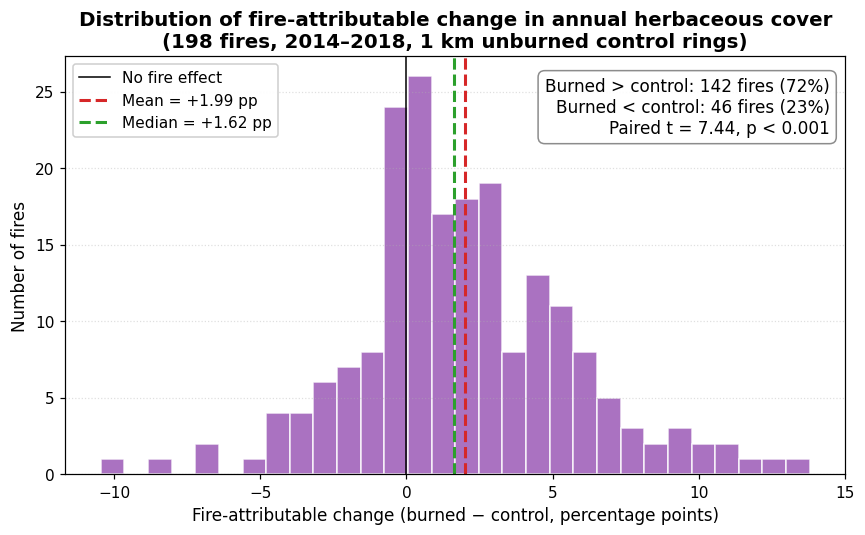

In [46]:
# Figure 6: Histogram of fire-attributable change (burned change minus control change)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

attr_mean   = combined['AttributableChange'].mean()
attr_median = combined['AttributableChange'].median()
n_pos = (combined['AttributableChange'] > 0).sum()
n_neg = (combined['AttributableChange'] < 0).sum()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(combined['AttributableChange'], bins=30, color='#9b59b6',
        edgecolor='white', alpha=0.85)

# Reference lines
ax.axvline(0, color='black', linestyle='-', linewidth=1, label='No fire effect')
ax.axvline(attr_mean, color='#d62728', linestyle='--', linewidth=2,
           label=f'Mean = {attr_mean:+.2f} pp')
ax.axvline(attr_median, color='#2ca02c', linestyle='--', linewidth=2,
           label=f'Median = {attr_median:+.2f} pp')

# Annotate split
ax.text(0.98, 0.95,
        f'Burned > control: {n_pos} fires ({n_pos/len(combined)*100:.0f}%)\n'
        f'Burned < control: {n_neg} fires ({n_neg/len(combined)*100:.0f}%)\n'
        f'Paired t = {t_stat:.2f}, p < 0.001',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='gray', alpha=0.9))

ax.set_xlabel('Fire-attributable change (burned − control, percentage points)')
ax.set_ylabel('Number of fires')
ax.set_title('Distribution of fire-attributable change in annual herbaceous cover\n'
             f'({len(combined)} fires, 2014–2018, 1 km unburned control rings)',
             fontweight='bold')
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_attributable_change_histogram.png')
plt.show()

## Phase 4: Stratification

Now that we've established a significant fire-attributable effect on average, we examine how the effect varies by:

1. **Ignition year** — does the response differ between fire years (potentially capturing year-to-year climate variability)?
2. **Fire size** — do larger fires show a stronger post-fire response?

**Burn severity** stratification would also be valuable but requires the MTBS severity rasters (separate download). Saved for later.

For each stratum we report sample size, mean fire-attributable change, and a paired t-test against zero.

### Stratify by ignition year

In [25]:
# Per-year summary of fire-attributable change
def paired_t_against_zero(values):
    if len(values) < 2:
        return np.nan, np.nan
    t, p = stats.ttest_1samp(values, 0)
    return t, p

year_rows = []
for yr, grp in combined.groupby('IgnitionYear'):
    t, p = paired_t_against_zero(grp['AttributableChange'].values)
    year_rows.append({
        'IgnitionYear': int(yr),
        'n_fires':      len(grp),
        'mean_attr':    grp['AttributableChange'].mean(),
        'median_attr':  grp['AttributableChange'].median(),
        'std_attr':     grp['AttributableChange'].std(),
        't_stat':       t,
        'p_value':      p,
    })
by_year = pd.DataFrame(year_rows)
by_year.round(3)

,IgnitionYear,n_fires,mean_attr,median_attr,std_attr,t_stat,p_value
0,2014,15,3.049,2.634,3.462,3.411,0.004
1,2015,9,3.965,2.128,4.797,2.479,0.038
2,2016,43,3.920,3.045,3.744,6.865,0.000
3,2017,80,1.927,2.061,3.107,5.549,0.000
4,2018,51,-0.212,0.120,3.515,-0.431,0.668


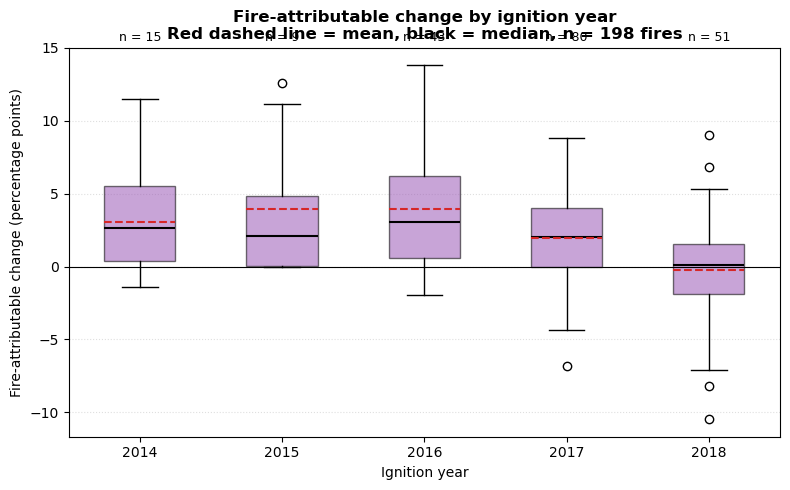

In [26]:
# Figure 7: Boxplot of fire-attributable change by ignition year
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
years_sorted = sorted(combined['IgnitionYear'].unique())
data = [combined.loc[combined['IgnitionYear']==y, 'AttributableChange'].values for y in years_sorted]

bp = ax.boxplot(data, tick_labels=years_sorted, patch_artist=True,
                showmeans=True, meanline=True,
                meanprops=dict(linestyle='--', color='#d62728', linewidth=1.5),
                medianprops=dict(color='black', linewidth=1.5))

for patch in bp['boxes']:
    patch.set(facecolor='#9b59b6', alpha=0.55, edgecolor='black')

ax.axhline(0, color='black', linewidth=0.8)

# Sample sizes on top
ymax = combined['AttributableChange'].max() + 1.5
for i, y in enumerate(years_sorted, start=1):
    n = (combined['IgnitionYear']==y).sum()
    ax.text(i, ymax, f'n = {n}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Ignition year')
ax.set_ylabel('Fire-attributable change (percentage points)')
ax.set_title('Fire-attributable change by ignition year\n'
             f'Red dashed line = mean, black = median, n = {len(combined)} fires',
             fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_attributable_by_year.png')
plt.show()

### Stratify by fire size

Fires are binned into three size classes using common thresholds in fire ecology:
- **Small:** < 10 km² (~2,500 acres)
- **Medium:** 10–50 km² (~2,500–12,500 acres)
- **Large:** ≥ 50 km² (~12,500 acres)

In [27]:
# Bin fires into size classes and summarize fire-attributable change per class
def size_class(km2):
    if km2 < 10:    return 'Small (<10 km²)'
    if km2 < 50:    return 'Medium (10–50 km²)'
    return 'Large (≥50 km²)'

combined['SizeClass'] = combined['BurnedAreaSqKm'].apply(size_class)

size_order = ['Small (<10 km²)', 'Medium (10–50 km²)', 'Large (≥50 km²)']
size_rows = []
for sc in size_order:
    grp = combined.loc[combined['SizeClass']==sc, 'AttributableChange']
    t, p = paired_t_against_zero(grp.values)
    size_rows.append({
        'SizeClass':   sc,
        'n_fires':     len(grp),
        'mean_attr':   grp.mean(),
        'median_attr': grp.median(),
        'std_attr':    grp.std(),
        't_stat':      t,
        'p_value':     p,
    })
by_size = pd.DataFrame(size_rows)
by_size.round(3)

,SizeClass,n_fires,mean_attr,median_attr,std_attr,t_stat,p_value
0,Small (<10 km²),77,2.029,1.834,4.027,4.421,0.000
1,Medium (10–50 km²),83,2.093,1.226,3.814,4.998,0.000
2,Large (≥50 km²),38,1.669,1.935,3.077,3.343,0.002


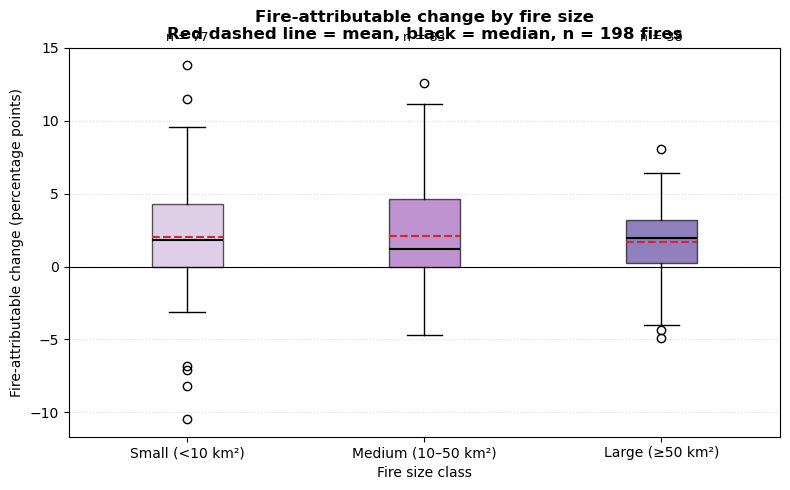

In [28]:
# Figure 8: Boxplot of fire-attributable change by fire size class
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
data = [combined.loc[combined['SizeClass']==sc, 'AttributableChange'].values for sc in size_order]

bp = ax.boxplot(data, tick_labels=size_order, patch_artist=True,
                showmeans=True, meanline=True,
                meanprops=dict(linestyle='--', color='#d62728', linewidth=1.5),
                medianprops=dict(color='black', linewidth=1.5))

# Color the boxes by intensity (small = light, large = dark)
colors = ['#cdb4db', '#9b59b6', '#553c9a']
for patch, c in zip(bp['boxes'], colors):
    patch.set(facecolor=c, alpha=0.65, edgecolor='black')

ax.axhline(0, color='black', linewidth=0.8)

# Sample sizes on top
ymax = combined['AttributableChange'].max() + 1.5
for i, sc in enumerate(size_order, start=1):
    n = (combined['SizeClass']==sc).sum()
    ax.text(i, ymax, f'n = {n}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Fire size class')
ax.set_ylabel('Fire-attributable change (percentage points)')
ax.set_title('Fire-attributable change by fire size\n'
             f'Red dashed line = mean, black = median, n = {len(combined)} fires',
             fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_attributable_by_size.png')
plt.show()

## Phase 5: Robustness checks

We probe two things that reviewers commonly ask:

1. **Buffer-distance sensitivity** — does the +1.99 pp result depend on our arbitrary 1 km buffer choice? We re-run the burned-vs-control comparison at 500 m, 1 km, 2 km, and 5 km and check whether the effect size is stable.
2. **Bootstrap confidence interval** — what's the 95% CI around the +1.99 pp mean? A non-parametric bootstrap (10,000 resamples) gives a robust answer that doesn't depend on normality assumptions.

### 5.1 Buffer-distance sensitivity

Re-extract control means at multiple buffer widths and compare the resulting fire-attributable effect. This may take a few minutes per buffer.

In [29]:
# Re-run the burned-vs-control comparison at multiple buffer widths
BUFFER_DISTANCES_M = [500, 1000, 2000, 5000]

sensitivity_records = []

with ExitStack() as stack:
    rasters = {y: stack.enter_context(rasterio.open(rcmap_clipped_path(y))) for y in RCMAP_YEARS}
    
    for buf_m in BUFFER_DISTANCES_M:
        print(f'Buffer {buf_m} m ...', end=' ', flush=True)
        ctrl_records = []
        for idx, row in fires_eligible.iterrows():
            ring_geom = build_control_ring(row.geometry, buffer_m=buf_m)
            if ring_geom is None:
                continue
            pre_mean,  _ = multi_year_mean(rasters, row.PreFireYears,  ring_geom)
            post_mean, _ = multi_year_mean(rasters, row.PostFireYears, ring_geom)
            if np.isnan(pre_mean) or np.isnan(post_mean):
                continue
            ctrl_records.append({
                'Event_ID':   row.Event_ID,
                'CtrlChange': post_mean - pre_mean,
            })
        ctrl_df = pd.DataFrame(ctrl_records)
        merged = pre_post.merge(ctrl_df, on='Event_ID', how='inner')
        merged['AttributableChange'] = merged['AbsChange'] - merged['CtrlChange']
        t, p = stats.ttest_rel(merged['AbsChange'], merged['CtrlChange'])
        sensitivity_records.append({
            'BufferDistanceM': buf_m,
            'n_fires':         len(merged),
            'mean_attr':       merged['AttributableChange'].mean(),
            'sem_attr':        merged['AttributableChange'].sem(),
            't_stat':          t,
            'p_value':         p,
        })
        print(f'n={len(merged)}, mean attr = {merged["AttributableChange"].mean():+.2f} pp, p = {p:.2e}')

sensitivity_df = pd.DataFrame(sensitivity_records)
sensitivity_df.round(3)

Buffer 500 m ... n=198, mean attr = +1.93 pp, p = 5.19e-12
Buffer 1000 m ... n=198, mean attr = +1.99 pp, p = 3.04e-12
Buffer 2000 m ... n=199, mean attr = +2.07 pp, p = 1.40e-12
Buffer 5000 m ... n=202, mean attr = +2.02 pp, p = 5.60e-12


,BufferDistanceM,n_fires,mean_attr,sem_attr,t_stat,p_value
0,500,198,1.931,0.263,7.349,0.0
1,1000,198,1.987,0.267,7.440,0.0
2,2000,199,2.065,0.273,7.568,0.0
3,5000,202,2.021,0.276,7.327,0.0


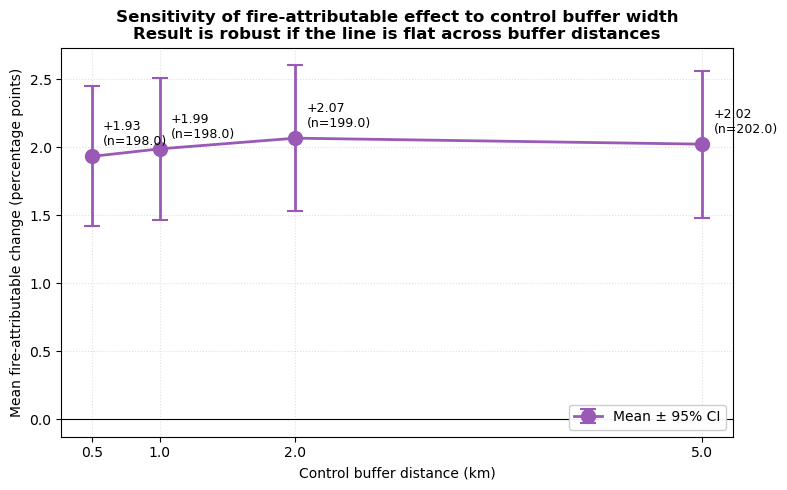

In [30]:
# Figure 9: Buffer-distance sensitivity plot
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

# Mean ± 95% CI (≈ 1.96 × SEM)
ax.errorbar(sensitivity_df['BufferDistanceM'] / 1000,
            sensitivity_df['mean_attr'],
            yerr=1.96 * sensitivity_df['sem_attr'],
            fmt='o-', color='#9b59b6', markersize=10,
            linewidth=2, capsize=6, capthick=1.5,
            label='Mean ± 95% CI')

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Annotate each point with its mean and n
for _, row in sensitivity_df.iterrows():
    ax.annotate(f'{row["mean_attr"]:+.2f}\n(n={row["n_fires"]})',
                xy=(row['BufferDistanceM']/1000, row['mean_attr']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, ha='left')

ax.set_xlabel('Control buffer distance (km)')
ax.set_ylabel('Mean fire-attributable change (percentage points)')
ax.set_title('Sensitivity of fire-attributable effect to control buffer width\n'
             'Result is robust if the line is flat across buffer distances',
             fontweight='bold')
ax.set_xticks(sensitivity_df['BufferDistanceM'] / 1000)
ax.legend(loc='lower right', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_buffer_sensitivity.png')
plt.show()

### 5.2 Bootstrap 95% CI for the fire-attributable effect

Resample the 198 fires with replacement 10,000 times, recompute the mean attributable change each time, and use the 2.5th and 97.5th percentiles of the resulting distribution as the 95% confidence interval.

In [31]:
# Bootstrap 95% CI for mean fire-attributable change
N_BOOT = 10_000
rng = np.random.default_rng(seed=42)

attr_values = combined['AttributableChange'].values
n = len(attr_values)

boot_means = np.empty(N_BOOT)
for i in range(N_BOOT):
    sample = rng.choice(attr_values, size=n, replace=True)
    boot_means[i] = sample.mean()

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
observed = attr_values.mean()

print(f'Observed mean attributable change: {observed:+.2f} pp')
print(f'Bootstrap 95% CI                 : [{ci_low:+.2f}, {ci_high:+.2f}] pp  (n={n}, {N_BOOT:,} resamples)')
print(f'Bootstrap mean                   : {boot_means.mean():+.2f} pp')
print(f'Bootstrap SE                     :  {boot_means.std():.3f} pp')

Observed mean attributable change: +1.99 pp
Bootstrap 95% CI                 : [+1.46, +2.52] pp  (n=198, 10,000 resamples)
Bootstrap mean                   : +1.99 pp
Bootstrap SE                     :  0.268 pp


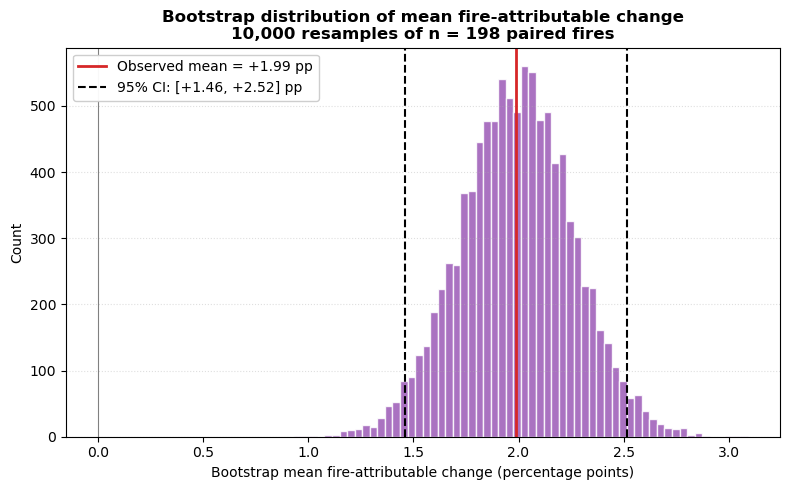

In [32]:
# Figure 10: Bootstrap distribution of the mean fire-attributable change
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(boot_means, bins=60, color='#9b59b6', alpha=0.85, edgecolor='white')

# Reference lines
ax.axvline(observed, color='#d62728', linestyle='-', linewidth=2,
           label=f'Observed mean = {observed:+.2f} pp')
ax.axvline(ci_low,  color='black', linestyle='--', linewidth=1.5,
           label=f'95% CI: [{ci_low:+.2f}, {ci_high:+.2f}] pp')
ax.axvline(ci_high, color='black', linestyle='--', linewidth=1.5)
ax.axvline(0,       color='gray',  linestyle='-',  linewidth=0.8)

ax.set_xlabel('Bootstrap mean fire-attributable change (percentage points)')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap distribution of mean fire-attributable change\n'
             f'{N_BOOT:,} resamples of n = {n} paired fires',
             fontweight='bold')
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_bootstrap_ci.png')
plt.show()

## Combined Phase 2 figure for the paper

Three Phase 2 panels combined into a single multi-panel figure (a, b, c) so they occupy the space of one publication figure.

In [ ]:
# Combined Phase 2 figure: (a) histogram, (b) pre-vs-post scatter, (c) spatial map of change
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
import matplotlib.gridspec as gridspec

mean_change   = pre_post['AbsChange'].mean()
median_change = pre_post['AbsChange'].median()
n_increase    = (pre_post['AbsChange'] > 0).sum()
n_decrease    = (pre_post['AbsChange'] < 0).sum()
increased     = pre_post['AbsChange'] > 0

fires_mapped = fires_eligible.merge(
    pre_post[['Event_ID', 'AbsChange']], on='Event_ID', how='inner'
)
v = max(abs(fires_mapped['AbsChange'].quantile(0.02)),
        abs(fires_mapped['AbsChange'].quantile(0.98)))

def strip_frame(ax):
    """Remove top and right spines, keep only bottom (x) and left (y) axis lines."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(13, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.25], hspace=0.30, wspace=0.20)

# (a) Histogram
ax_a = fig.add_subplot(gs[0, :])
ax_a.hist(pre_post['AbsChange'], bins=30, color='#4c72b0',
          edgecolor='white', alpha=0.85)
ax_a.axvline(0, color='black', linestyle='-', linewidth=1, label='No change')
ax_a.axvline(mean_change, color='#d62728', linestyle='--', linewidth=2,
             label=f'Mean = {mean_change:+.2f} pp')
ax_a.axvline(median_change, color='#2ca02c', linestyle='--', linewidth=2,
             label=f'Median = {median_change:+.2f} pp')
inc_txt = f'Increase: {n_increase} fires ({n_increase/len(pre_post)*100:.0f}%)'
dec_txt = f'Decrease: {n_decrease} fires ({n_decrease/len(pre_post)*100:.0f}%)'
ax_a.text(0.98, 0.95, inc_txt + chr(10) + dec_txt,
          transform=ax_a.transAxes, ha='right', va='top',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                    edgecolor='gray', alpha=0.9))
ax_a.set_xlabel('Post − Pre annual herbaceous cover (percentage points)')
ax_a.set_ylabel('Number of fires')
ax_a.legend(loc='upper left', frameon=True, framealpha=0.95)
strip_frame(ax_a)
ax_a.text(-0.04, 1.05, '(a)', transform=ax_a.transAxes,
          fontsize=15, fontweight='bold', va='top')

# (b) Pre vs Post scatter
ax_b = fig.add_subplot(gs[1, 0])
ax_b.scatter(pre_post.loc[increased,  'PreMean'], pre_post.loc[increased,  'PostMean'],
             s=24, color='#d62728', alpha=0.65, edgecolor='white', linewidth=0.5,
             label=f'Increase ({increased.sum()})')
ax_b.scatter(pre_post.loc[~increased, 'PreMean'], pre_post.loc[~increased, 'PostMean'],
             s=24, color='#4c72b0', alpha=0.65, edgecolor='white', linewidth=0.5,
             label=f'Decrease / no change ({(~increased).sum()})')
lo, hi = 0, max(pre_post['PreMean'].max(), pre_post['PostMean'].max()) + 2
ax_b.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1, label='1:1 line')
ax_b.set_xlim(lo, hi); ax_b.set_ylim(lo, hi)
ax_b.set_xlabel('Pre-fire annual herbaceous cover (%)')
ax_b.set_ylabel('Post-fire annual herbaceous cover (%)')
ax_b.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9)
strip_frame(ax_b)
ax_b.text(-0.10, 1.05, '(b)', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# (c) Spatial map of AbsChange — no axes/frame at all
ax_c = fig.add_subplot(gs[1, 1])
gb.plot(ax=ax_c, facecolor='#f7f7f7', edgecolor='black', linewidth=1.0)
fires_mapped.plot(
    ax=ax_c, column='AbsChange', cmap='RdBu_r',
    vmin=-v, vmax=v, edgecolor='black', linewidth=0.2,
    legend=True,
    legend_kwds={
        'label': 'Change in cover (pp)',
        'orientation': 'horizontal',
        'shrink': 0.8, 'pad': 0.04,
    },
)
minx, miny, maxx, maxy = gb.total_bounds
ax_c.set_xlim(minx, maxx)
ax_c.set_ylim(miny, maxy)
ax_c.set_axis_off()
ax_c.text(-0.04, 1.05, '(c)', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

plt.savefig(FIG_DIR / 'fig2_phase2_combined.png')
plt.show()


## Combined Phase 3 figure for the paper

Burned-vs-unburned panels combined into a single figure (a) per-fire scatter and (b) attributable-change histogram.

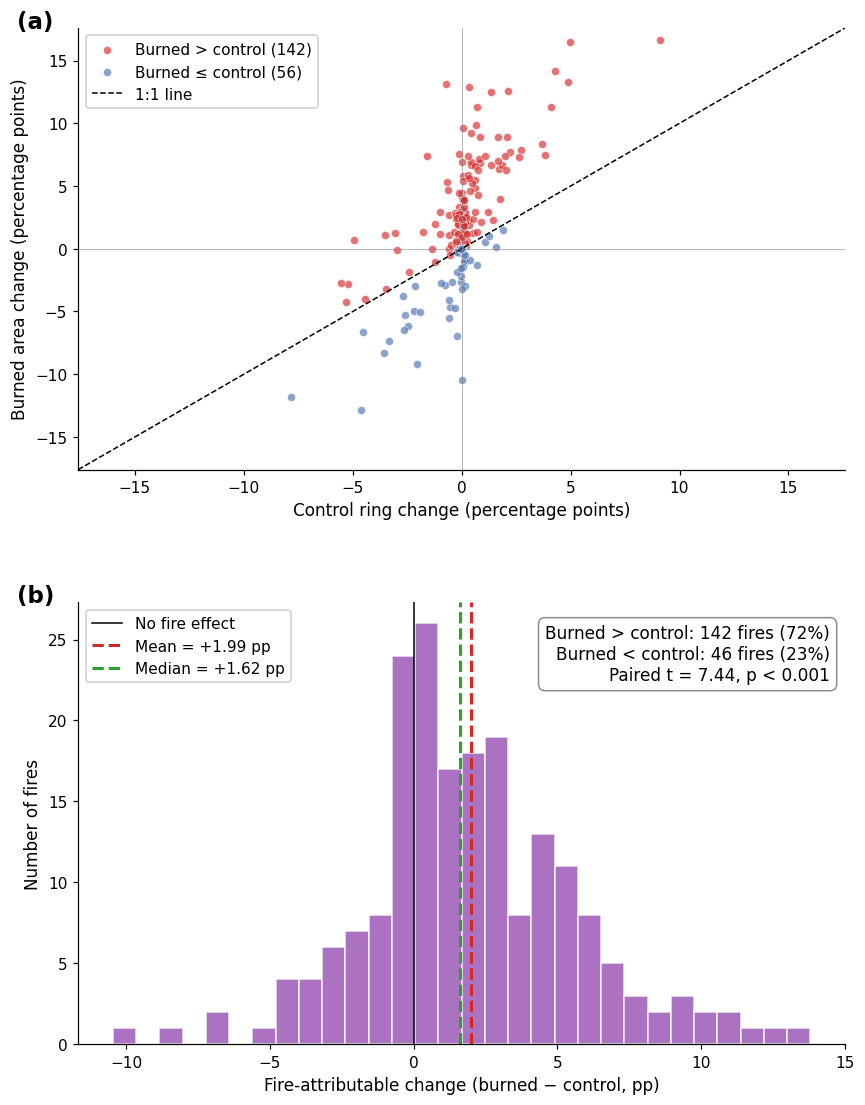

In [55]:
# Combined Phase 3 figure: (a) burned vs control scatter, (b) attributable-change histogram
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
import matplotlib.gridspec as gridspec

attr_mean   = combined['AttributableChange'].mean()
attr_median = combined['AttributableChange'].median()
n_pos = (combined['AttributableChange'] > 0).sum()
n_neg = (combined['AttributableChange'] < 0).sum()

def strip_frame(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(2, 1, hspace=0.30)

# (a) Burned vs control scatter
ax_a = fig.add_subplot(gs[0, 0])
above = combined['AttributableChange'] > 0
ax_a.scatter(combined.loc[above,  'CtrlChange'], combined.loc[above,  'AbsChange'],
             s=28, color='#d62728', alpha=0.65, edgecolor='white', linewidth=0.5,
             label=f'Burned > control ({above.sum()})')
ax_a.scatter(combined.loc[~above, 'CtrlChange'], combined.loc[~above, 'AbsChange'],
             s=28, color='#4c72b0', alpha=0.65, edgecolor='white', linewidth=0.5,
             label=f'Burned ≤ control ({(~above).sum()})')
lim = max(abs(combined['AbsChange']).max(), abs(combined['CtrlChange']).max()) + 1
ax_a.plot([-lim, lim], [-lim, lim], color='black', linestyle='--', linewidth=1, label='1:1 line')
ax_a.axhline(0, color='gray', linewidth=0.6, alpha=0.6)
ax_a.axvline(0, color='gray', linewidth=0.6, alpha=0.6)
ax_a.set_xlim(-lim, lim); ax_a.set_ylim(-lim, lim)
ax_a.set_xlabel('Control ring change (percentage points)')
ax_a.set_ylabel('Burned area change (percentage points)')
ax_a.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10)
strip_frame(ax_a)
ax_a.text(-0.08, 1.04, '(a)', transform=ax_a.transAxes,
          fontsize=15, fontweight='bold', va='top')

# (b) Histogram of attributable change
ax_b = fig.add_subplot(gs[1, 0])
ax_b.hist(combined['AttributableChange'], bins=30, color='#9b59b6', alpha=0.85, edgecolor='white')
ax_b.axvline(0, color='black', linestyle='-', linewidth=1, label='No fire effect')
ax_b.axvline(attr_mean, color='#d62728', linestyle='--', linewidth=2,
             label=f'Mean = {attr_mean:+.2f} pp')
ax_b.axvline(attr_median, color='#2ca02c', linestyle='--', linewidth=2,
             label=f'Median = {attr_median:+.2f} pp')
pos_txt = f'Burned > control: {n_pos} fires ({n_pos/len(combined)*100:.0f}%)'
neg_txt = f'Burned < control: {n_neg} fires ({n_neg/len(combined)*100:.0f}%)'
ax_b.text(0.98, 0.95, pos_txt + chr(10) + neg_txt + chr(10) + f'Paired t = {t_stat:.2f}, p < 0.001',
          transform=ax_b.transAxes, ha='right', va='top',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))
ax_b.set_xlabel('Fire-attributable change (burned − control, pp)')
ax_b.set_ylabel('Number of fires')
ax_b.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10)
strip_frame(ax_b)
ax_b.text(-0.08, 1.04, '(b)', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

plt.savefig(FIG_DIR / 'fig3_phase3_combined.png')
plt.show()


## Combined Phase 4 figure for the paper

Stratification panels combined: (a) by ignition year, (b) by fire size class.

In [ ]:
# Combined Phase 4 figure: (a) by ignition year, (b) by fire size class
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
import matplotlib.gridspec as gridspec

def strip_frame(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(9, 11))
gs = gridspec.GridSpec(2, 1, hspace=0.35)

# (a) By ignition year
ax_a = fig.add_subplot(gs[0, 0])
years_sorted = sorted(combined['IgnitionYear'].unique())
data_yr = [combined.loc[combined['IgnitionYear']==y, 'AttributableChange'].values for y in years_sorted]
bp = ax_a.boxplot(data_yr, tick_labels=years_sorted, patch_artist=True,
                  showmeans=True, meanline=True,
                  meanprops=dict(linestyle='--', color='#d62728', linewidth=1.5),
                  medianprops=dict(color='black', linewidth=1.5))
for patch in bp['boxes']:
    patch.set(facecolor='#9b59b6', alpha=0.55, edgecolor='black')
ax_a.axhline(0, color='black', linewidth=0.8)
ymax = combined['AttributableChange'].max() + 1.5
for i, y in enumerate(years_sorted, start=1):
    n = (combined['IgnitionYear']==y).sum()
    ax_a.text(i, ymax, f'n = {n}', ha='center', va='bottom', fontsize=9)
ax_a.set_xlabel('Ignition year')
ax_a.set_ylabel('Fire-attributable change (percentage points)')
strip_frame(ax_a)
ax_a.text(-0.13, 1.08, '(a)', transform=ax_a.transAxes,
          fontsize=15, fontweight='bold', va='top')

# (b) By fire size class
ax_b = fig.add_subplot(gs[1, 0])
size_order = ['Small (<10 km²)', 'Medium (10–50 km²)', 'Large (≥50 km²)']
if 'SizeClass' not in combined.columns:
    def _sc(km2):
        if km2 < 10: return 'Small (<10 km²)'
        if km2 < 50: return 'Medium (10–50 km²)'
        return 'Large (≥50 km²)'
    combined['SizeClass'] = combined['BurnedAreaSqKm'].apply(_sc)
data_sz = [combined.loc[combined['SizeClass']==sc, 'AttributableChange'].values for sc in size_order]
bp = ax_b.boxplot(data_sz, tick_labels=size_order, patch_artist=True,
                  showmeans=True, meanline=True,
                  meanprops=dict(linestyle='--', color='#d62728', linewidth=1.5),
                  medianprops=dict(color='black', linewidth=1.5))
colors = ['#cdb4db', '#9b59b6', '#553c9a']
for patch, c in zip(bp['boxes'], colors):
    patch.set(facecolor=c, alpha=0.65, edgecolor='black')
ax_b.axhline(0, color='black', linewidth=0.8)
for i, sc in enumerate(size_order, start=1):
    n = (combined['SizeClass']==sc).sum()
    ax_b.text(i, ymax, f'n = {n}', ha='center', va='bottom', fontsize=9)
ax_b.set_xlabel('Fire size class')
ax_b.set_ylabel('Fire-attributable change (percentage points)')
strip_frame(ax_b)
ax_b.text(-0.13, 1.08, '(b)', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

plt.savefig(FIG_DIR / 'fig4_phase4_combined.png')
plt.show()
